In [ ]:
# Import required libraries
import numpy as np

from sklearn.decomposition import PCA # Class that performs PCA
from sklearn.datasets import load_breast_cancer # To load the dataset on the fly
from sklearn.preprocessing import StandardScaler # To standardize the data

import matplotlib.pyplot as plt # Visualization

In [ ]:
# Dimensionality Reduction using Principal Component Analysis (PCA)
#
# In this lab, we perform Principal Component Analysis on the breast cancer
# dataset.
#
# PCA is a technique used to reduce the dimensionality of a dataset while
# retaining as much of the original variance as possible.
#
# This can be useful for visualizing high-dimensional data or for improving the
# performance of machine learning algorithms by removing noise and
# multicollinearity.
#
# We have primarily used it here to visualize the

In [ ]:
# Load the Breast Cancer dataset
dataset = load_breast_cancer()
dataset.data
dataset.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

## Dataset Description and PCA's Role

This dataset contains information about breast cell nuclei, with each sample described by 30 measurements (features). These features include things like the size, shape, and texture of the cell nuclei. The goal is to determine if a mass is malignant (cancerous) or benign (not cancerous) based on these features.

Having 30 features makes it hard to visualize the data directly. Principal Component Analysis (PCA) helps by reducing these 30 features to a smaller number, in this case, two main components. PCA finds the directions in the data where there is the most variation.

By using PCA to reduce the data to 2 components, we can:

1.  **Simplify the data:** Make it easier to see patterns by going from 30 dimensions to just 2.
2.  **See the separation:** The plot shows how well the first two components separate the malignant and benign cases, indicating that PCA captures the key differences.
3.  **Reduce noise:** Focus on the most important variations in the data, ignoring less important ones.

PCA makes this high-dimensional breast cancer data easier to understand and visualize, especially for seeing the difference between cancerous and non-cancerous cells.

In [ ]:
# Get the data from the dataset
from sklearn.datasets import load_breast_cancer # Ensure import for dataset loading
dataset = load_breast_cancer() # Added to ensure dataset is defined
data = dataset.data

# Display the (number of rows, dimensionality of each row)
data.shape

(569, 30)

In [ ]:
# Standardize the data
#
# Standardizing the data is important for PCA because it is sensitive to the
# scale of the features.
#
# Print the scaled data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)
scaled_data.shape

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


(569, 30)

In [ ]:
# Create a PCA instance with 2 components
#
# We choose 2 components to reduce the data to a 2-dimensional space,
#  which is useful for visualization.
n_components = 2
pca = PCA(n_components=n_components)

In [ ]:
import pandas as pd

# Get the feature names from the dataset
feature_names = dataset.feature_names

# Fit PCA to the scaled data if it hasn't been fitted already
# This step calculates the principal components based on the scaled data.
pca.fit(scaled_data)

# Create a DataFrame to better visualize the principal components' loadings
# Each row is a principal component, and each column is an original feature
components_df = pd.DataFrame(pca.components_, columns=feature_names, index=[f'Principal Component {i+1}' for i in range(n_components)])

print("Principal Components Loadings:")
display(components_df)

Principal Components Loadings:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
Principal Component 1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
Principal Component 2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


The table above shows the loadings (coefficients) for each original feature on Principal Component 1 and Principal Component 2. A higher absolute value for a coefficient indicates that the corresponding original feature has a stronger influence on that principal component.

For example, if 'mean radius' has a high positive loading on Principal Component 1, it means that PC1 increases as 'mean radius' increases. If it has a high negative loading, PC1 decreases as 'mean radius' increases.

By examining these values, you can infer which original features are most strongly associated with each principal component and, consequently, which features contribute most to the variance captured by that component.

In [ ]:
# Fit PCA to the scaled data
#
# This step calculates the principal components based on the scaled data.
pca.fit(scaled_data)

PCA(n_components=2)

In [ ]:
# Transform the data to its principal components
#
# This step applies the calculated principal components to the scaled data to reduce its dimensionality.
transformed_data = pca.transform(scaled_data)
transformed_data.shape

(569, 2)

In [ ]:
# Explained variance ratio
# The explained variance ratio indicates the proportion of the dataset's variance that lies along each principal component.
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)

# Principal components
# The principal components are the directions in the original feature space along which the variance is maximized.
principal_components = pca.components_
print("Principal Components:", principal_components)

Explained Variance Ratio: [0.44272026 0.18971182]
Principal Components: [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [ ]:
# Load the target variable for coloring the plot
target = dataset.target

# Create a scatter plot of the transformed data
plt.figure(figsize=(8, 6))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], c=target, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Breast Cancer Dataset (2 Components)')
plt.colorbar(label='Target (0: Malignant, 1: Benign)')
plt.grid(True)
plt.show()

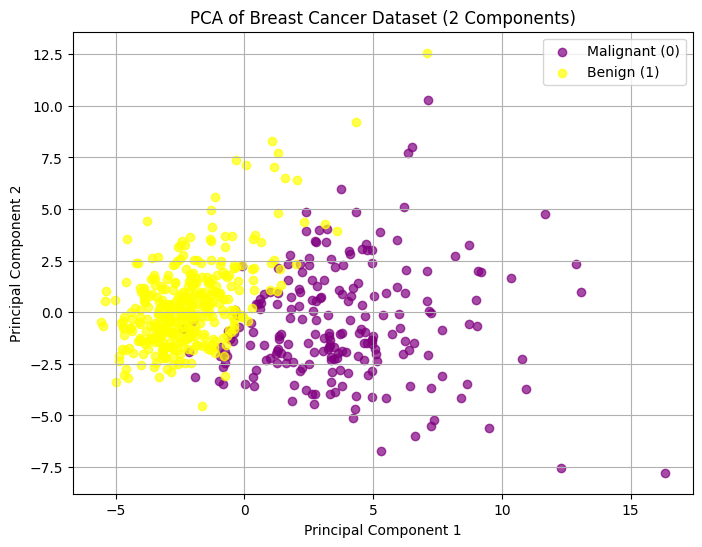

In [ ]:
# Load the target variable for coloring the plot
target = dataset.target

# Create a scatter plot of the transformed data
plt.figure(figsize=(8, 6))

# Separate data by target class for legend
transformed_data_malignant = transformed_data[target == 0]
transformed_data_benign = transformed_data[target == 1]

# Plot each class separately
plt.scatter(transformed_data_malignant[:, 0], transformed_data_malignant[:, 1], c='purple', label='Malignant (0)', alpha=0.7)
plt.scatter(transformed_data_benign[:, 0], transformed_data_benign[:, 1], c='yellow', label='Benign (1)', alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Breast Cancer Dataset (2 Components)')
plt.legend() # Add the legend
plt.grid(True)
plt.show()

In [ ]:
# Final interpretation:

# The scatter plot shows a clear separation between the two target classes
# (Malignant and Benign) in the 2-dimensional space created by the first two
# principal components.
#
# This suggests that these two components capture a
# significant amount of the variance that differentiates the two classes,
# making it much easier to visualize the data and potentially build a
# classification model on this reduced-dimensional data.

# The explained variance ratio shows that the first principal component captures
# about 44.3% of the variance, and the second captures about 19.0%. Together,
# they capture approximately 63.3% of the total variance in the original
# 30-dimensional dataset.

# While this doesn't capture all the variance, the clear separation in the plot
# indicates that the most important information for distinguishing between the
# two classes is largely preserved in these two components.

# Conclusion: PCA has transformed the 30-dimensional data into a 2-dimensional
# representation where the classes are visually distinguishable, which is a
# meaningful outcome for understanding the data structure and potentially
# for downstream tasks like classification.

In [ ]:
import pandas as pd

# Create a DataFrame from the transformed data
# transformed_data and target are available from previous steps.
df = pd.DataFrame(data=transformed_data, columns=['Principal Component 1', 'Principal Component 2'])

# Add the target variable to the DataFrame
df['Target'] = target

df.to_excel('final_dataset.xlsx',index=False)

In [ ]:
import pandas as pd

# Create a DataFrame from the transformed data
df = pd.DataFrame(data=transformed_data, columns=['Principal Component 1', 'Principal Component 2'])

# Add the target variable to the DataFrame
df['Target'] = target

# Display the first few rows of the new DataFrame
display(df.head())

,Principal Component 1,Principal Component 2,Target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0
